In [43]:
{
    1:"data preparing and loading",
    2:"building a model",
    3:"fitting the model to data",
    4:"making predictions and evaluating a model",
    5:"saving and loading a model",
    6:"putting it all together"
}

{1: 'data preparing and loading',
 2: 'building a model',
 3: 'fitting the model to data',
 4: 'making predictions and evaluating a model',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [44]:

import torch
from torch import nn
import matplotlib.pyplot as plt 


## 1. data preparing and loading


In [45]:
# crate know parameters
weight=0.7
bais=0.3

# create
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bais
X[:10],y[:10],len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [46]:
# splitting data into training and test sets
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [47]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")
    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")
    plt.legend(prop={"size":14})

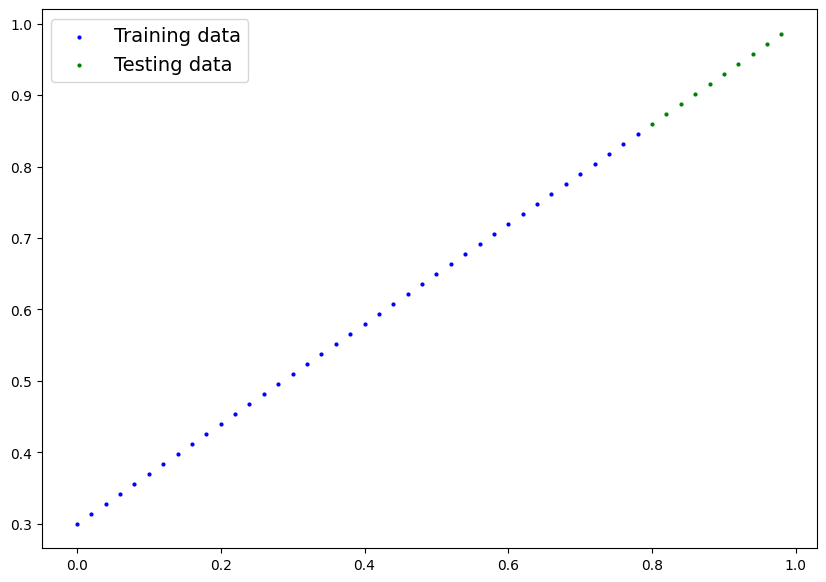

In [48]:
plot_predictions()

In [49]:
# building model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weights*x+self.bias

In [50]:
torch.manual_seed(42)
# creating an instance of the model
model_0=LinearRegressionModel()
model_0.parameters(),list(model_0.parameters())

(<generator object Module.parameters at 0x7cb4c9eaec00>,
 [Parameter containing:
  tensor([0.3367], requires_grad=True),
  Parameter containing:
  tensor([0.1288], requires_grad=True)])

In [51]:
# list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

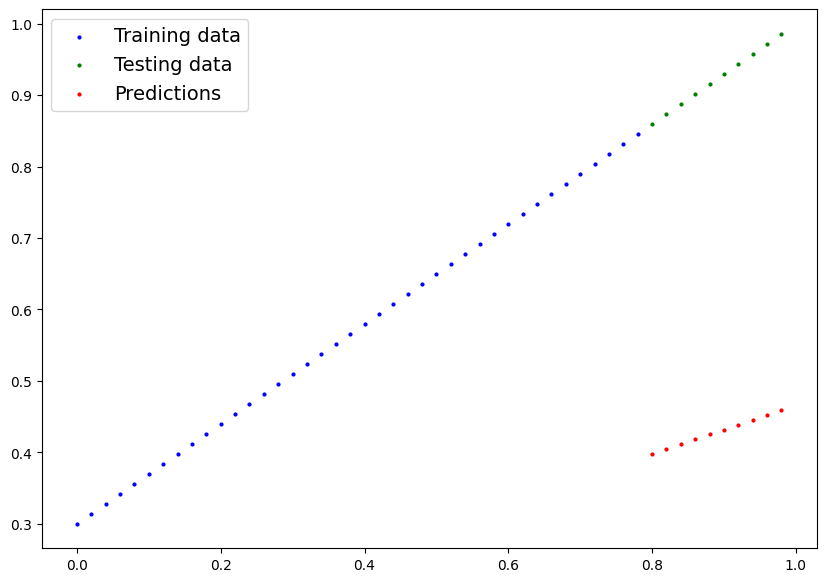

In [52]:
y_preds=model_0(X_test)
plot_predictions(predictions=y_preds.detach())
y_preds

In [53]:
# infering on the model  this is more preferred way to infer on a model
with torch.inference_mode():
    y_preds=model_0(X_test)
y_preds,y_test

(tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

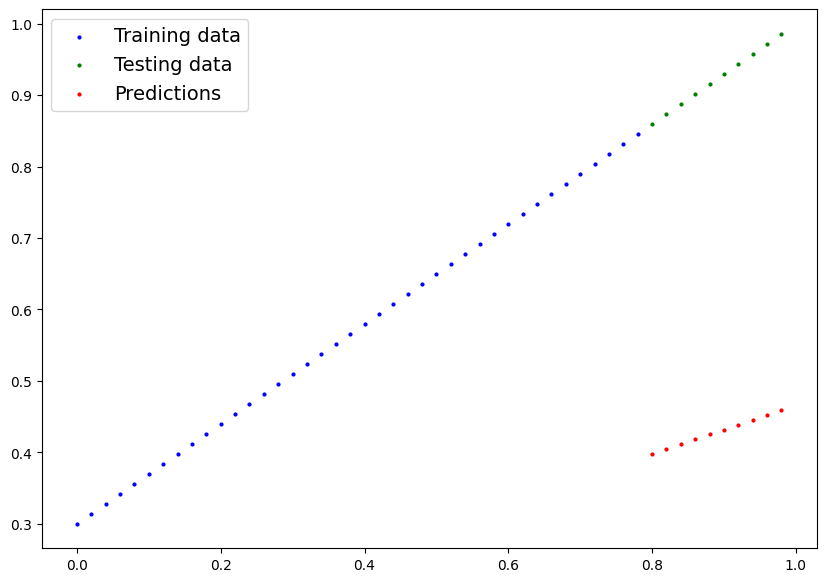

In [54]:
plot_predictions(predictions=y_preds)

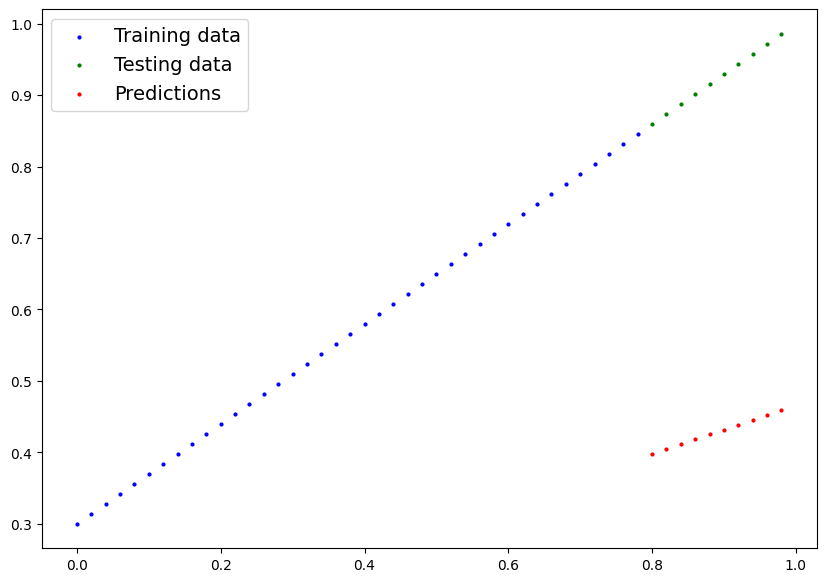

In [55]:
with torch.no_grad():
    y_preds=model_0(X_test)
plot_predictions(predictions=y_preds)
# not preferred

In [56]:
# set up loass function
loss_fn=nn.L1Loss()


# set up and optimizer
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)
# stochastic gradient descent is used as optimizer and learning rate is set to 0.01

In [57]:
# building the training loop
epochs=200
epoch_counts=[]
loss_values=[]
test_loss_values=[]
# loop through the data
for epoch in range(epochs):
    model_0.train() # in training mode, it sets all parameters that requires_grad=True to require gradients
    # 1. forward pass
    y_pred=model_0(X_train)
    # 2. calculate the loss
    loss=loss_fn(y_pred,y_train)
    # 3. backpropagation
    optimizer.zero_grad() # zero the gradients before backpropagation
    loss.backward() # peroform backpropagation to calculate the gradients
    optimizer.step() # update the parameters using the optimizer
    # optimizer.zero_grad() # zero the gradients after updating the parameters but its not necessary to do it here because we will zero the gradients at the beginning of the next epoch
    
    # test the model
    test_pred=model_0(X_test)
    loss=loss_fn(test_pred,y_test)
    if epoch%10==0:
        epoch_counts.append(epoch)
        loss_values.append(loss.detach().numpy())
        test_loss_values.append(loss.detach().numpy())
        print(f"Epoch: {epoch}| Loss: {loss:.4f} | Test Loss: {loss:.4f}")
        print(model_0.state_dict())

Epoch: 0| Loss: 0.4811 | Test Loss: 0.4811
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10| Loss: 0.3464 | Test Loss: 0.3464
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20| Loss: 0.2173 | Test Loss: 0.2173
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30| Loss: 0.1446 | Test Loss: 0.1446
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40| Loss: 0.1136 | Test Loss: 0.1136
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50| Loss: 0.0992 | Test Loss: 0.0992
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60| Loss: 0.0889 | Test Loss: 0.0889
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70| Loss: 0.0806 | Test Loss: 0.0806
OrderedDict({'weights': tensor([0.5288]), 'bias': tensor([0.3718])})
Epoch: 80| Loss: 0.0723 | Test Loss: 0.0723
OrderedDict({'weights': tensor([0.5459]), 'bias': ten

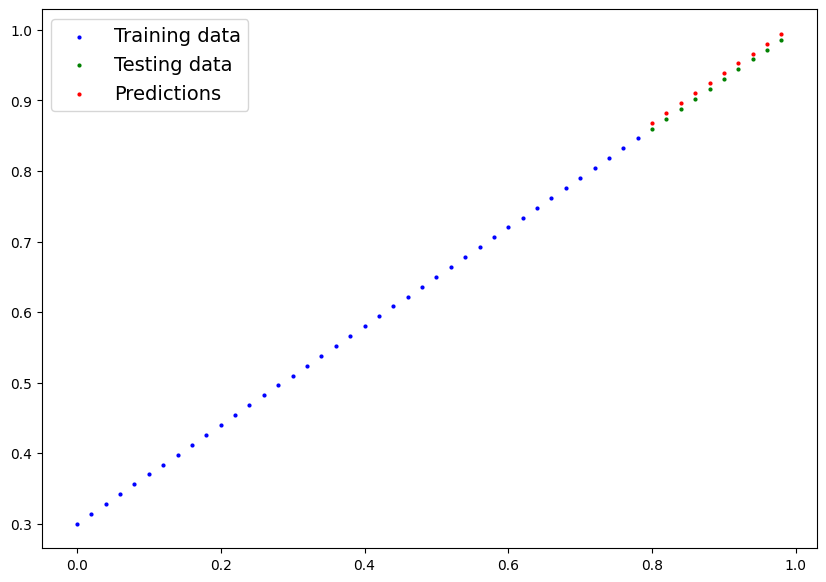

In [58]:
# testing code
model_0.eval() # turns off different setting in the model that is not need for evaluation and inference like dropout and batch normalization
with torch.inference_mode(): # torch.no_grad() can also be used here but torch.inference_mode() is more efficient because it turns off the autograd engine and it also turns off the training mode of the model which is not needed for evaluation and inference
    y_preds=model_0(X_test)
plot_predictions(predictions=y_preds)

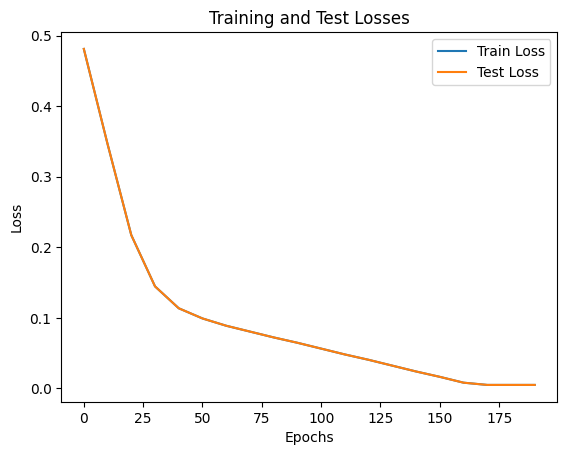

In [59]:
plt.plot(epoch_counts,loss_values,label="Train Loss")
plt.plot(epoch_counts,test_loss_values,label="Test Loss")
plt.title("Training and Test Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## saving a model in pytorch

In [60]:

# method 1: saving the entire model using torch.save() and loading it using torch.load() -> this method saves the entire model including the architecture and the parameters but it is not recommended because it can cause issues when loading the model on a different machine or when loading the model after a long time because the architecture of the model might have changed and it can also cause issues when loading the model on a different version of PyTorch because the architecture of the model might have changed in different versions of PyTorch

# method 2: saving the state_dict of the model torch.nn.Module.load_state_dict() -> this is the recommended way to save a model because it saves the parameters of the model and it can be loaded on any machine and it can be loaded after a long time because it does not depend on the architecture of the model but it requires you to have the architecture of the model defined in your code when loading the model



In [61]:
# saving the model
from pathlib import Path

# create model directory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# create model save path
MODEL_NAME="01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

# saving the model dict state
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)

In [62]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Jun 17 15:22 01_pytorch_workflow_model_0.pth


## loading the saved model

In [63]:
loaded_model_0=LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))
# this is the recommended way to load a model because it saves the parameters of the model and it can be loaded on any machine and it can be loaded after a long time because it does not depend on the architecture of the model but it requires you to have the architecture of the model defined in your code when loading the model

<All keys matched successfully>

In [64]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

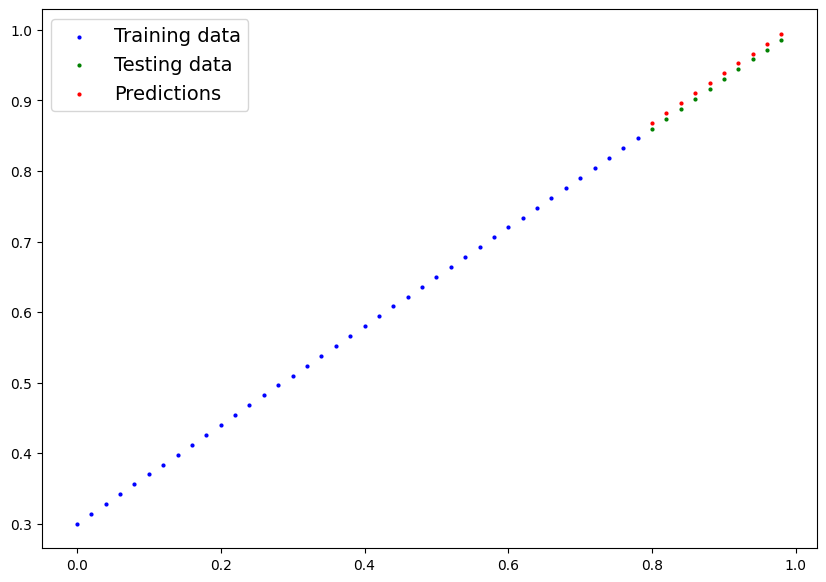

In [65]:
# make some predicts
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds=loaded_model_0(X_test)
plot_predictions(predictions=loaded_model_preds)

In [66]:
y_preds==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## putting all together

Epoch: 0| Loss: 0.5440 | Test Loss: 0.5709
Epoch: 50| Loss: 0.0979 | Test Loss: 0.0942
Epoch: 100| Loss: 0.0912 | Test Loss: 0.0934
Epoch: 150| Loss: 0.0912 | Test Loss: 0.0931
Epoch: 200| Loss: 0.0912 | Test Loss: 0.0929
Epoch: 250| Loss: 0.0911 | Test Loss: 0.0926
Epoch: 300| Loss: 0.0911 | Test Loss: 0.0923
Epoch: 350| Loss: 0.0910 | Test Loss: 0.0921
Epoch: 400| Loss: 0.0910 | Test Loss: 0.0917
Epoch: 450| Loss: 0.0910 | Test Loss: 0.0914
Epoch: 500| Loss: 0.0909 | Test Loss: 0.0912
Epoch: 550| Loss: 0.0909 | Test Loss: 0.0909
Epoch: 600| Loss: 0.0909 | Test Loss: 0.0906
Epoch: 650| Loss: 0.0908 | Test Loss: 0.0904
Epoch: 700| Loss: 0.0908 | Test Loss: 0.0901
Epoch: 750| Loss: 0.0907 | Test Loss: 0.0898
Epoch: 800| Loss: 0.0907 | Test Loss: 0.0896
Epoch: 850| Loss: 0.0907 | Test Loss: 0.0892
Epoch: 900| Loss: 0.0906 | Test Loss: 0.0891
Epoch: 950| Loss: 0.0906 | Test Loss: 0.0887
OrderedDict({'linear_layer.weight': tensor([[0.6560]]), 'linear_layer.bias': tensor([0.3295])})


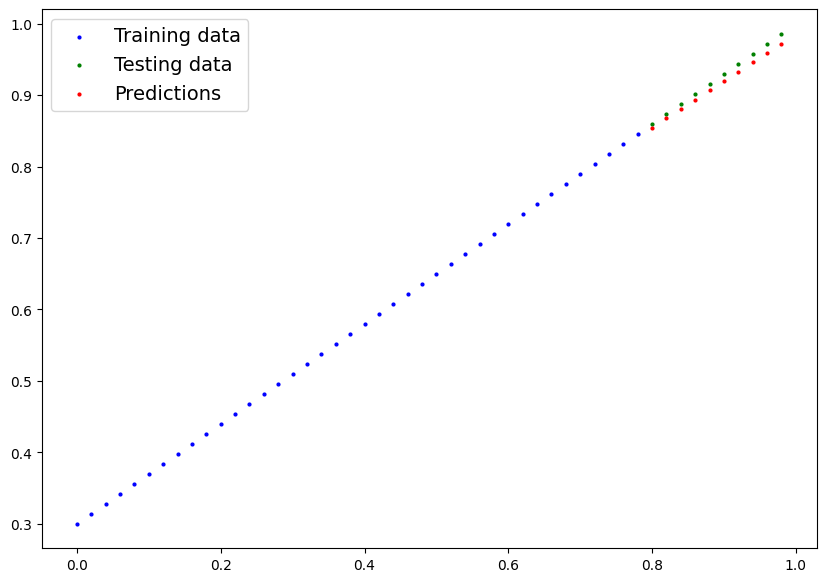

In [74]:
import torch
from torch import nn
import matplotlib.pyplot as plt
device='cuda'if torch.cuda.is_available() else 'cpu'
# create some data using linear regression formula with some noise
torch.manual_seed(42)
weight=0.7
bias=0.3
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias+0.1*torch.randn(X.shape)
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
# data should be in same device
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer=nn.Linear(in_features=1,out_features=1)
    
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.linear_layer(x)
torch.manual_seed(42)
model_1=LinearRegressionModel().to(device)
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.01)
epochs=1000
# training loop
for epoch in range(epochs):
    model_1.train()
    y_pred=model_1(X_train.to(device))
    loss=loss_fn(y_pred,y_train.to(device))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # testing the model
    model_1.eval()
    with torch.inference_mode():
        test_pred=model_1(X_test.to(device))
        test_loss=loss_fn(test_pred,y_test.to(device))
    if epoch%50==0:
        print(f"Epoch: {epoch}| Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")
print(model_1.state_dict())

# making predictions
model_1.eval()
with torch.inference_mode():
    y_preds=model_1(X_test.to(device))
plot_predictions(predictions=y_preds.cpu())
from pathlib import Path
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME="01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME
torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

In [75]:
!ls -l models


total 8
-rw-r--r-- 1 root root 2117 Jun 17 15:22 01_pytorch_workflow_model_0.pth
-rw-r--r-- 1 root root 2181 Jun 17 15:25 01_pytorch_workflow_model_1.pth


In [78]:
loaded_model_1=LinearRegressionModel().to(device)
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_1.to(device)

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [79]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6560]])),
             ('linear_layer.bias', tensor([0.3295]))])

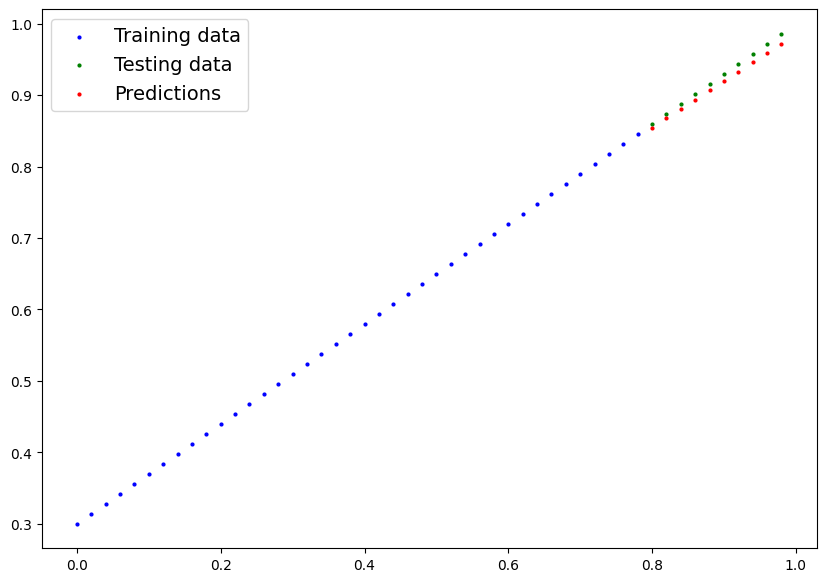

In [81]:
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_preds=loaded_model_1(X_test.to(device))
plot_predictions(predictions=loaded_model_preds.cpu())